<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK3_1_transcript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9. 비지도 학습

### 비지도 학습 방법의 예

- 군집clustering
> 비슷한 샘플을 **클러스터**cluster로 모음.    
사용처: 데이터 분석, 고객 분류, 추천 시스템, 검색 엔진, 이미지 분할, 준지도 학습, 차원 축소

- 이상치 탐지 outlier datection
> '정상' 데이터가 어떻게 보이는지 학습 > 비정상 샘플 감지
예시: 제조 라인에서 결함 제품 감지 or 시계열 데이터에서 새로운 트렌드 발견

- 밀도 추정 density estimation
> 데이터셋 생성 확률 과정random prodcess의 확률 밀도 함수probability density function(PDF) 추정
사용처: 이상치 탐지(밀도가 매우 낮은 영역에 놓인 샘플이 이상치일 가능성 높음), 데이터 분석, 시각화



## 1. 군집
- 비슷한 샘플을 구별해 하나의 **클러스터**cluster 또는 비슷한 샘플의 그룹으로 할당하는 작업
- 각 샘플은 하나의 그룹에 할당(분류도 마찬가지이지만 군집은 비지도 학습.)

군집의 적용 예시
> 고객 분류(추천 시스템), 데이터 분석, 차원축소 기법(친화성 측정), 이상치 탐지(부정 거래 감지), 준지도 학습, 검색 엔진, 이미지 분할

클러스터
- 보편적인 정의 없음.(실제로 상황에 따라 다름)
- 어떤 알고리즘에서는 **센트로이드**centroid라 부르는 특정 포인트를 중심으로 모인 샘플을 찾음
- 샘플이 밀집되어 연속된 영역 찾음
- 클러스터는 어떤 모양이든 될 수 있음.
- 계층적으로 클러스터의 클러스터를 찾음.

유명 군집 알고리즘: k-평균, DBSCAN

### 1.1 K-평균
- 반복 몇 번으로 레이블 없는 데이터셋을 빠르고 효율적으로 클러스터로 묶을 수 있는 간단한 알고리즘
- 로이드-포지 알고리즘이라고도 부름.

In [19]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

blob_centers = np.array([[ 0.2, 2.3], [-1.5 , 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])

blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

In [20]:
from sklearn.cluster import KMeans

k=5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

상단의 코드 설명
- 각 샘플은 다섯 개의 클러스터 중 하나에 할당
- 군집에서 각 샘플의 **레이블**label: 알고리즘이 샘플에 할당한 클러스터의 인덱스
- KMeans의 인스턴스는 labels 인스턴스 변수에 훈련된 샘플의 레이블을 가지고 있음.

In [3]:
y_pred

array([2, 2, 4, ..., 1, 4, 2], dtype=int32)

In [4]:
y_pred is kmeans.labels_

True

In [21]:
# 알고리즘이 찾은 센트로이드 다섯 개 확인

kmeans.cluster_centers_

array([[-0.066884  ,  2.10378803],
       [-2.79290307,  2.79641063],
       [-2.80214068,  1.55162671],
       [-1.47468607,  2.28399066],
       [ 0.47042841,  2.41380533]])

In [22]:
# 새로운 샘플에 가장 가까운 센트로이드의 클러스터 할당

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 4, 1, 1], dtype=int32)

클러스터의 결정 경계를 그려 얻을 수 있는 보로노이 다이어그램Voronoi tessellation

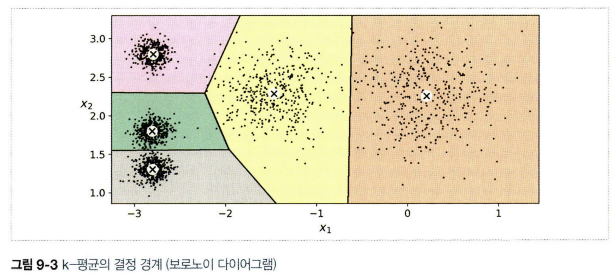

- k-평균 알고리즘은 클러스터의 크기가 많이 다르면 잘 작동하지 않음.
- 샘플을 클러스터에 할당할 때 센트로이드까지 거리를 고려하는 것이 전부이기 때문

#### 그렇다면 어떻게?
> **하드 군집**(hard clustering, 샘플을 하나의 클러스터에 해당하는 것) 보다는 **소프트 군집**(soft clustering, 클러스터마다 샘플에 점수를 부여하는 것)이 유용.
>> 여기서 점수는 샘플과 센트로이드 사이의 거리
>> 혹은 가우시안 방사기저 함수와 같은 유사도 점수(similarity score-친화성 점수)
>> 센트로이드까지 거리는 작을수록 해당 클러스터에 가깝고 유사도 점수는 높을수록 해당 클러스터에 가까움.

#### KMeans 클래스의 transform() 메서드: 샘플과 각 센트로이드 사이의 거리 반환

In [26]:
kmeans.transform(X_new)

# 이런 방식으로 거리를 변환하면 매우 효율적인 비선형 차원 축소 기법이 될 수 있음.

array([[0.12347236, 2.9042344 , 2.83778629, 1.50178217, 0.62652832],
       [3.06863967, 5.84739223, 5.81943941, 4.48368889, 2.56319474],
       [3.06697984, 0.29040966, 1.4618254 , 1.685008  , 3.51958769],
       [2.95975563, 0.36159148, 0.96879317, 1.54053323, 3.47149865]])

#### k-평균 알고리즘
> (센트로이드가 주어진다고 가정 시, 모든 샘플에 가장 가까운 센트로이드의 클러스터 할당. or 레이블이 주어진다면 클러스터에 속한 샘플의 평균 계산 후 센트로이드 계산)
<br>

1.  센트로이드 랜덤 선정(무작위의 k개 샘플을 뽑아 그 위치를 센트로이드로 설정)
2. 샘플에 레이블을 할당하고 센트로이드를 업데이트
3. ...를! 센트로이드에 변화가 없을 때까지 계속 반복
4. 제한된 횟수 안에 수렴하는 것을 보장. 무한하게 반복되지 않음.

K-평균 알고리즘 작동 시각화

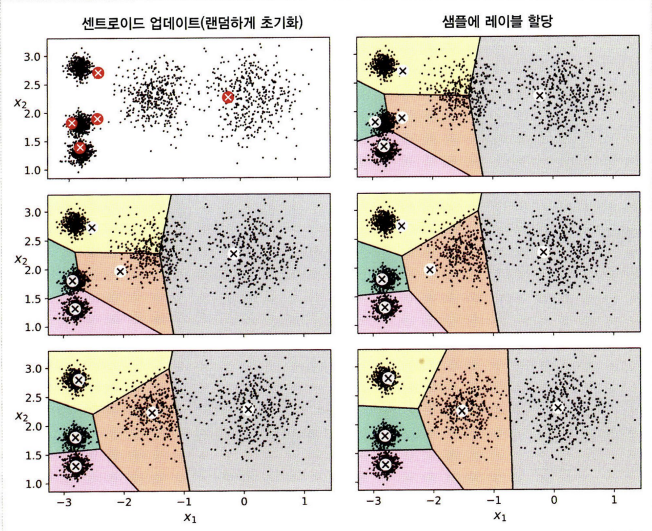

알고리즘은 수렴하는 것이 보장되지만 적절한 솔루션으로 수렴하지 못할 수 있음.(= 지역 최적점으로 수렴할 수 있음)
> 이 여부는 센트로이드 초기화에 달려있음.

그렇다면 센트로이드는 어떻게 초기화하는가?

#### 센트로이드 초기화 방법
- 센트로이드 위치를 근사하게 알 수 있다면(ex. 또 다른 군집 알고리즘을 먼저 실행) init 매개변수에 센트로이드 리스트를 담은 넘파이 배열을 지정 > n_init를 1로 설정

In [14]:
good_init = np.array([[-3,3], [-3,2], [-1,2], [0,2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)

- 랜덤 초기화를 다르게 하여 여러 번 알고리즘을 실행하고 가장 좋은 솔루션 선택 (랜덤 초기화 횟수는 n_init 매개변수로 조절, 기본값은 10)
> 최선의 솔루션을 알 수 있는 방법: 각 샘플과 가장 가까운 센트로이드 사이의 평균 제곱거리이며 모델의 **이너셔**inertia가 가장 낮은 모델을 반환하면 됨.
> ``` inertia_ ``` 변수 사용.




In [23]:
kmeans.inertia_

224.0743312251571

```score()``` 메서드는 이너셔의 음숫값을 반환
- 사이킷런의 '큰 값이 좋은 것이다'라는 규칙을 따라야 하기 때문.

In [24]:
kmeans.score(X)

-224.0743312251571

#### k-평균++ 알고리즘
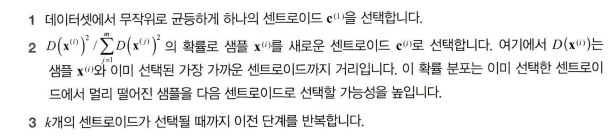

#### k-평균 속도 개선과 미니배치 k-평균

찰스 엘칸이 제안한 개선점
- 불필요한 거리 계산을 많이 피함으로써 알고리즘의 속도를 높임
> 방법: 삼각 부등식 triangle inequality을 사용. (두 점 사이의 직선은 항상 가장 짧은 거리)
- 샘플과 센트로이드 사이의 거리를 위한 하한선과 상한선을 유지 (KMeans에서 기본으로 사용함.)

데이비드 스컬리가 시한 다른 변종
- 전체 데이터셋을 사용해 반복하지 않고 각 반복마다 미니배치를 사용해 센트로이드를 조금씩 이동. > 알고리즘 속도를 3~4배 높임

```MiniBatchKMeans``` 알고리즘 사용

In [25]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5)

속도 측면: 미니배치 k-평균 알고리즘 > 일반 k-평균 알고리즘

이너셔: 미니배치 k-평균 알고리즘 < 일반 k-평균 알고리즘

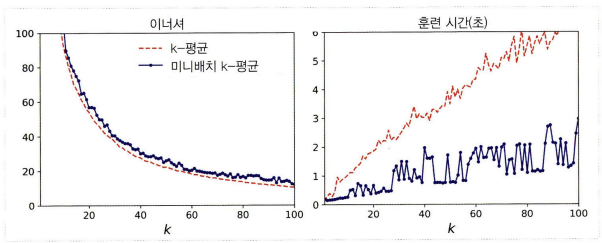

#### 최적의 클러스터 개수 찾기

- 이너셔는 k가 증가함에 따라 점점 작아지므로 k(클러스터 개수)를 선택할 때 좋은 성능지표가 아님.
- 클러스터가 늘어날수록 각 샘플은 가까운 센트로이드에 더 가깝게 됨. > 이너셔는 더 작아짐.

최선의 클러스터 개수를 선택하는 정확한 방법  : **실루엣 점수** silhouette score
- 모든 샘플에 대한 **실루엣 계수**silhouette coefficient의 평균.

계산 방법: (b-a) / max(a, b)   <br>
> a: 동일한 클러스터에 있는 다른 샘플까지 평균거리
> b: 가장 가까운 클러스터(의 샘플)까지 평균거리

실루엣 계수
- 범위: -1부터 +1까지
> +1에 가까움: 자신의 클러스터 안에 잘 속해 있고 다른 클러스터와는 멀리 떨어짐
> -1에 가까움: 이 샘플이 잘못된 클러스터에 할당됨
- 사이킷런의 ```silhouette_score()``` 함수를 사용함. 데이터셋에 있는 모든 샘플과 할당된 레이블 전달

In [28]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.6267891051050735)

모든 샘플의 실루엣 계수를 할당된 클러스터와 계숫값으로 정렬하여 그리면 더 많은 정보가 있는 그래프를 얻을 수 있음
> **실루엣 다이어그램**silhouette diagram

- 클러스터마다 칼 모양의 그래프가 그려짐
- 그래프의 높이: 클러스터가 포함하고 있는 샘플의 개수
- 너비: 이 클래스에 포함된 샘플의 정렬된 실루엣 계
- 수직 파선: 각 클러스터 개수에 해당하는 실루엣 점수


### 1.2 k-평균의 한계

장점
- 속도가 빠르고 확장이 용이

단점
- 최적이 아닌 솔루션을 피하려면 알고리즘을 여러 번 실행해야 함. + 클러스터 개수를 지정해야 함
- 클러스터의 크기나 밀집도가 서로 다르거나 원형이 아닐 경우 잘 작동하지 않음.

### 1.3 군집을 사용한 이미지 분할

**이미지 분할** image segmentation
- 이미지를 세그먼트segment 여러 개로 분할하는 작업

**시맨틱 분할** semantic segmentation
- 동일한 종류의 물체에 속한 모든 픽셀은 같은 세그먼트에 할당

시맨틱 또는 인스턴스 분할instance segmentation에서 최고 수준의 성능을 내려면 합성곱 신경망을 사용한 복잡한 모델을 사용해야 함.

**색상 분할**color segmentation 수행
- 동일한 색상을 가진 픽셀을 같은 세그먼트에 해당

In [32]:
from matplotlib.image import imread # or 'from imageio import imread
import matplotlib.pyplot as plt

image = plt.imread("/content/ladybug.png")
image.shape

이미지는 3D 배열로 표현됨. (높이, 너비, 컬러 채널 개수)
> 컬러 채널 개수: 3(RGB)
> 각 픽셀에 대해 빨강, 초록, 파랑의 강도를 담은 3D 벡터가 있음. (0.0 ~ 1.0 혹은 0~255)

- 흑백: 채널이 1개
- 투명도를 위해 **알파 채널** alpha channel을 가진 이미지나 위성 이미지: 채널이 3개보다 많음



(533, 800, 3)

In [33]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

1. 모든 초록색을 하나의 컬러 클러스터로 만들기
2. 각 색상에 대해 그 픽셀의 컬러 클러스터의 평균 컬러를 찾음
3. 모든 초록색은 모두 밝은 초록색으로 바뀔 수 있음. (초록 클러스터의 평균 색이 밝은 초록이라 가정)
4. 긴 색상의 리스트를 원본 이미지와 동일한 크기로 바꿈.

k-평균은 비슷한 크기의 클러스터를 만드는 경향이 있음.

### 1.4 군집을 사용한 전처리

 - 차원 축소에 효과적인 방법
 - 지도 학습 알고리즘을 적용하기 전에 전처리 단계로 사용할 수 있음

In [34]:
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(return_X_y=True)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits)

In [36]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [37]:
log_reg.score(X_test, y_test)

0.9533333333333334

In [39]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50)),
    ("log_reg", LogisticRegression()),
])

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                ('log_reg', LogisticRegression())])

In [41]:
pipeline.score(X_test, y_test)

0.9555555555555556

가장 좋은 k값: 교차 검증에서 가장 좋은 분류 성능을 내는 값

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = dict(kmeans__n_clusters=range(2, 100))
grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.2s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.2s


...

[CV] END ..............................kmeans__n_clusters=99; total time=   0.4s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END ..............................kmeans__n_clusters=99; total time=   0.4s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                                       ('log_reg', LogisticRegression())]),
             param_grid={'kmeans__n_clusters': range(2, 100)}, verbose=2)

In [43]:
grid_clf.best_params_

{'kmeans__n_clusters': 51}

In [44]:
grid_clf.score(X_test, y_test)

0.9511111111111111

### 1.5 군집을 사용한 준지도 학습

- 군집을 사용하는 사례2: 준지도 학습
- 레이블이 없는 데이터가 많고, 레이블이 있는 데이터는 적을때 사용

In [45]:
n_labeled = 50
log_reg = LogisticRegression()
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

0.8066666666666666

In [69]:
k = 50
kmeans = KMeans(n_clusters=k)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

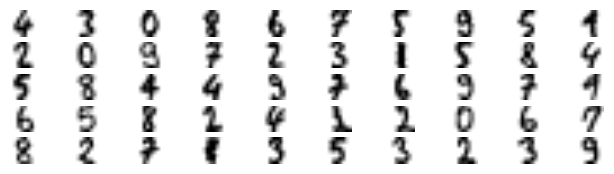

In [70]:
plt.figure(figsize=(8, 2))

for index, X_representative_digit in enumerate(X_representative_digits):
  plt.subplot(k // 10, 10, index + 1)
  plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
             interpolation="bilinear")
  plt.axis('off')

plt.show()

In [72]:
y_representative_digits = np.array([4, 3, 0, 8, 6, 7, 5, 9, 5, 4,
                                                                    2, 0, 9, 7, 2, 3, 1, 5, 8, 4,
                                                                    5, 8, 4, 4, 9, 7, 6, 9, 7, 9,
                                                                    6, 5, 8 ,2, 4, 2, 2, 0, 6, 7,
                                                                    8, 2, 7, 8, 3, 5, 3, 2, 3, 9])

In [73]:
log_reg = LogisticRegression()
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8377777777777777

샘플에 레이블을 부여하는 것은 비용이 많이 들고 어려움.
- 무작위 샘플 대신 대표 샘플에 레이블을 할당하는 것이 좋은 방법

> 어? 그렇다면 레이블을 동일한 클러스터에 있는 모든 샘플에 전파하게 된다면?
#### 그것이 **레이블 전파**label propagation

In [74]:
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [75]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8488888888888889

In [76]:
# 센트로이드와 가까운 샘플의 20%에만 레이블 전파 후 확인

percentile_closest = 20

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
  in_cluster = (kmeans.labels_ == i)
  cluster_dist = X_cluster_dist[in_cluster]
  cutoff_distance = np.percentile(cluster_dist, percentile_closest)
  above_cutoff = (X_cluster_dist > cutoff_distance)
  X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [77]:
log_reg = LogisticRegression()
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8422222222222222

In [78]:
np.mean(y_train_partially_propagated == y_train[partially_propagated])

np.float64(0.9212328767123288)

#### 능동 학습
- 모델과 훈련 세트를 지속적으로 향상하기 위해 다음 단계로 **능동 학습**active learning을 몇번 반복
- 전문가가 학습 알고리즘과 상호작용하여 알고리즘이 요청할 때 특정 샘플의 레이블을 제공
- **불확실성 샘플링** uncertainty sampling

1. 지금까지 수집한 레이블된 샘플에서 모델 훈련
2. 모델이 가장 불확실하게 예측한 샘플을 전문가에게 보내 레이블 붙임
3. 레이블을 부여하는 노력만큼의 성능이 향상되지 않을 때까지 이를 반복



### 1.6 DBSCAN

- 밀집된 연속적 지역을 클러스터로 정의

작동방식         
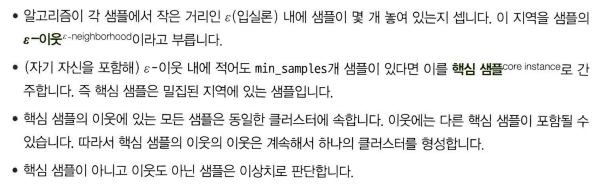

- 모든 클러스터가 충분히 밀집되어 있고 밀집되지 않은 지역과 잘 구분될 때 좋은 성능을 냄.

In [79]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [80]:
# 모든 샘플의 레이블은 labels_에 저장되어 있음.

dbscan.labels_

array([ 0,  0,  1,  2,  1, -1,  2,  0,  1,  1,  0,  1,  3,  3,  1,  1,  1,
        1,  4, -1,  2, -1, -1,  1,  1,  0,  1,  5,  5,  6,  1,  2,  3,  2,
        3,  1,  2,  3,  8,  1,  1,  1,  0,  7,  1,  7, -1,  2,  3,  3,  2,
        4,  1,  5,  6,  1,  3,  1,  7, -1,  5,  2,  1, -1,  0,  1,  1,  5,
        2,  5,  3,  5,  1,  2, -1,  4,  5,  2, -1,  8,  7,  5,  8,  3,  1,
        4,  0,  9,  3,  2,  1,  1,  1,  1,  7,  1, -1,  3,  1,  1,  0,  2,
        8,  3,  6,  5, -1,  1,  5,  5,  2,  0,  5,  1,  1,  1,  1,  2,  1,
        3,  7,  2,  8,  6,  2,  1,  8,  0,  4,  0,  7, -1,  2,  7,  5,  8,
        9,  2,  7,  5,  1, -1,  4, -1, -1,  7,  5,  8,  2,  5,  1,  2,  1,
        7,  7,  1,  0,  1,  5,  2,  1,  0,  2,  0,  0,  6,  3, -1,  1,  4,
        1,  2,  7,  1, -1,  1,  6,  2,  2,  1,  2, -1,  5,  5,  0,  2,  5,
        0,  2,  7,  2,  2,  1,  2,  1, -1,  2,  8,  1,  2,  7,  1,  7,  2,
        1,  0, -1,  1,  5,  2,  5,  7,  0,  6,  2,  2,  5,  0,  3,  2, -1,
        2,  1,  5,  8,  7

In [81]:
# 핵심 샘플의 인덱스는 core_sample_indices_에서 확인 가능

len(dbscan.core_sample_indices_)

791

In [82]:
dbscan.core_sample_indices_

array([  0,   2,   3,   4,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  17,  18,  20,  23,  24,  25,  26,  27,  28,  29,  30,  31,
        32,  33,  34,  35,  36,  37,  39,  40,  41,  42,  43,  44,  45,
        47,  48,  49,  51,  52,  53,  54,  55,  56,  57,  58,  60,  62,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  75,  76,  77,
        79,  81,  82,  83,  84,  85,  87,  88,  89,  90,  92,  93,  94,
        95,  97,  98,  99, 100, 101, 102, 103, 104, 105, 107, 108, 109,
       110, 113, 114, 116, 117, 118, 119, 125, 126, 127, 128, 129, 130,
       132, 133, 134, 135, 136, 137, 138, 140, 142, 145, 147, 148, 149,
       150, 151, 152, 153, 154, 156, 157, 158, 159, 160, 161, 162, 164,
       165, 168, 169, 170, 171, 172, 173, 176, 177, 178, 179, 182, 184,
       185, 187, 188, 189, 190, 191, 192, 193, 194, 197, 198, 199, 201,
       202, 203, 204, 205, 207, 208, 209, 210, 211, 212, 213, 214, 215,
       216, 217, 219, 221, 222, 223, 224, 225, 227, 228, 230, 23

In [83]:
dbscan.components_

array([[-0.02353677,  0.98819741],
       [ 0.27437339, -0.24505064],
       [-0.72473956,  0.77476333],
       ...,
       [ 0.07712514,  0.06820308],
       [ 0.84390719,  0.61174721],
       [-0.94724715,  0.34010196]])

DBSCAN 클래스는 predict() 메서드를 제공하지 않고 ```fit_predict()``` 메서드를 제공.
> 새로운 샘플에 대해 클러스터를 예측할 수 없음.
- 사용자가 필요한 예측기를 선택해야 함.

In [85]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [86]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2,1]])
knn.predict(X_new)

array([2, 1, 5, 7])

In [87]:
knn.predict_proba(X_new)

array([[0.  , 0.12, 0.88, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.04, 0.96, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.44, 0.  , 0.  , 0.  , 0.54, 0.  , 0.  , 0.  , 0.  , 0.02],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.  , 0.  ]])

최대 거리를 사용하면 두 클러스터에서 멀리 떨어진 샘플을 이상치로 간단히 분류 가능. KNeighborsClassifier의 ```kneighbors()``` 메서드를 사용

In [88]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  1, 10, -1])

- DBSCAN은 매우 간단하지만 강력한 알고리즘.
- 클러스터의 모양과 개수에 상관없이 감지할 수 있는 능력이 있음.
- 이상치에 안정적, 하이퍼파라미터가 두 개(eps, min_samples)뿐.

- 클러스터간의 밀집도가 크게 다르면 모든 클러스터를 올바르게 잡아내는 것이 불가능
- 계산 복잡도는 샘플 개수에 대해 거의 선형적으로 증가


### 1.7 다른 군집 알고리즘

- 병합 군집
- BIRCH
- 평균-이동
- 유사도 전파
- 스펙트럼 군집